$\textbf{1. Gráfica de datos experimentales}$

El archivo $\textit{manchasolares.txt}$ (adjunto), contiene el numero observado de manchas solares en el Sol en cada mes desde enero de 1749. El archivo contiene dos columnas
de numeros, la primera es el mes y la segunda el número de manchas solares.

a) Escribe un programa que lea los datos y haga una gráfica de las manchas solares en función del tiempo.  ́

Primero tengo que leer los datos, me convendrá separar los datos en meses y número de manchas solares. Por suerte, ya tengo un programa que hace eso.

In [4]:
archivo = open("manchasolares.txt", "r")
lista = []
for i in archivo.readlines():
    lista.append(i)
lista2 = []
for i in lista:
    lista2.append(i.split())
Mes = []
N = []
for i in lista2:
    Mes.append(float(i[0]))
    N.append(float(i[1]))

Ahora que tengo los datos, la gráfica no debería de ser problema mayor. Yo digo que basta con las funciones básicas y el título

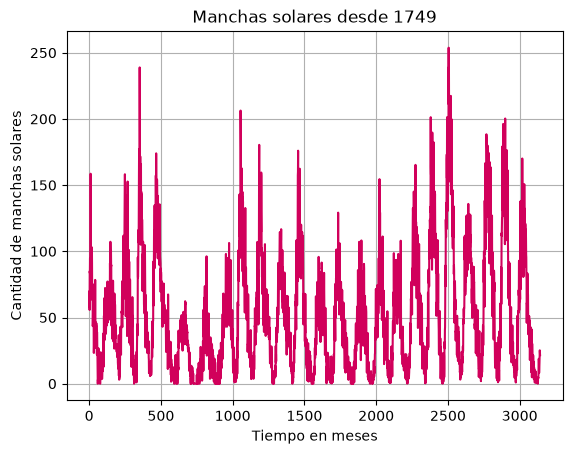

In [5]:
import matplotlib.pyplot as plt
plt.grid()
plt.title("Manchas solares desde 1749")
plt.xlabel("Tiempo en meses")
plt.ylabel("Cantidad de manchas solares")
plt.plot(Mes,N, color ='#D1005B')

b) Modifica tu programa para mostrar solo los primeros 1000 datos (experimentales) en la gráfica.

R: No tengo ni la menor idea de cómo hacer eso, tendré que husmear el notebook o buscarlo en internet.

R2: Fue un error pensar que necesitaba hacer algo desde mathplotlib, pues puedo seleccionar a mano los datos que yo quiera desde los array de numpy

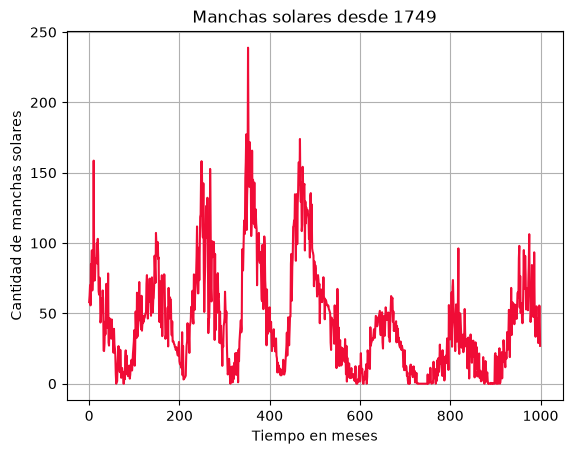

In [11]:
plt.grid()
plt.title("Manchas solares desde 1749")
plt.xlabel("Tiempo en meses")
plt.ylabel("Cantidad de manchas solares")
plt.plot(Mes[:1000],N[:1000], color ='#F00C36') #uso slices

c) Modifica nuevamente tu programa para calcular y graficar la $\textbf{media (promedio) móvil}$ de los datos, definida por:

$Y_k = \frac{1}{2r+1} \displaystyle\sum_{m=-r}^{r} y_{k+m}$

Donde $r = 5$ (en este caso) y $y_k$ son los numeros de manchas solares.

El programa debe graficar tanto los datos originales como la media móvil en el mismo grafico, sólo sobre los primeros 1000 datos.  ́

El problema es calcular la media móvil esa. Dado que depende de k, quizá sirva programarla como una función y luego pedirle a matplotlib que la grafique variando k dentro de los primeros 1000 datos; el problema de esto es que los primeros y últimos 5 datos no se pueden calcular, pero voy a ignorar ese detalle épicamente.

In [14]:
def Y(l,k,r):
    '''Hay que ingresar la lista l de donde se sacarán los datos, el dato k al que hay que calcularle el promedio, y una r de los datos alrededor'''
    Y = 1/(2*r+1)*l[k-r] #primer término de la suma
    for m in range(-r+1,r+1): #desde el siguiente término hasta r
        Y = Y + 1/(2*r+1) * l[k+m]
    return Y

In [18]:
Y(N,2,2) #parece que sí jala

66.26

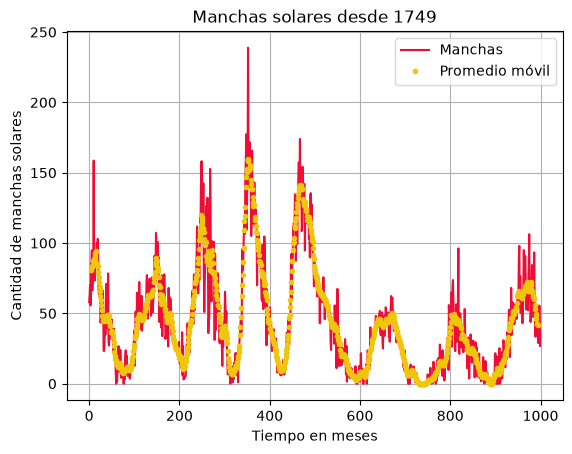

In [31]:
plt.grid()
plt.title("Manchas solares desde 1749")
plt.xlabel("Tiempo en meses")
plt.ylabel("Cantidad de manchas solares")
plt.plot(Mes[:1000],N[:1000], color ='#F00C36', label='Manchas') #uso slices
plt.plot(Mes[5:995],pm, '.', color = '#F0C60C', label = 'Promedio móvil')

plt.legend()

#no me gusta cómo se ve, pero no estoy seguro de cómo hacer que se vea mejor

No funcionó como yo esperaba. Pero no importa, puedo hacer una lista con los valores que necesito.

In [21]:
pm = []
r=5
for i in range(5,995): #corto el intervalo porque no puedo calcular los 1000
    pm.append(Y(N,i,r))

$\textbf{2. Gráfica de Feigenbaum (Caos determinista)}$

El mapeo logístico se define por la ecuación:

$x_{n+1}=rx_n(1-x_n)$

Para valores arbitrarios $r,x_n$

$\textit{a)}$ Apoyate en el programa que vimos en clase y escribe un programa que muestre el comportamiento del mapeo logístico mediante una grafica.  ́

Pregunta: ¿cuál programa? wwwwwwwwwwwwwwwwwwwwwwwwwwwww


Me limitaré a seguir las instrucciones.

In [2]:
import numpy as np
R=[] #aquí meteré los valores de r para graficar
x8=[] #aquí meteré los valores finales de x que se graficarán con las r de arriba

for r in np.arange(1,4.01,0.01): #El rango de los valores de r
    x=1/2 #establezco el punto de inicio de x para cada r
    for i in range(1000): #primeras mil iteraciones de x para cada r
        x=r*x*(1-x)
    for i in range(1000): #otras mil iteraciones, pero estas sí las voy a guardar, junto a su r
        x=r*x*(1-x)
        R.append(r)
        x8.append(x)

/tmp/ipykernel_5588/3356348055.py:8: RuntimeWarning: overflow encountered in scalar multiply
  x=r*x*(1-x)


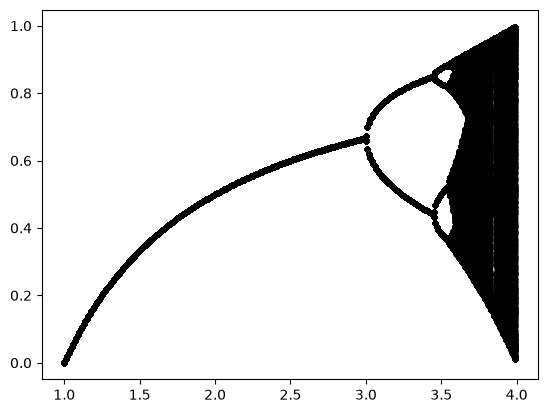

In [98]:
#procedo a graficar
plt.plot(R,x8,'k.')

Se parece más a una flor torcida que a un árbol, pero bueno. Parece que el primer cambio notable en la gráfica es alrededor de r=3, luego hay otros dos alrededor de r=3.4, y a partir de ahí se aloca.

In [129]:
#versión 2
r=np.array([i for i in np.arange(1,4.01,0.01)]) #Todos los valores de r
x = np.ones(len(r))/2 #lista con la misma longitud que r, todos los valores empiezan en 1/2

In [143]:
for i in range(1000):
    x=r*x*(1-x)

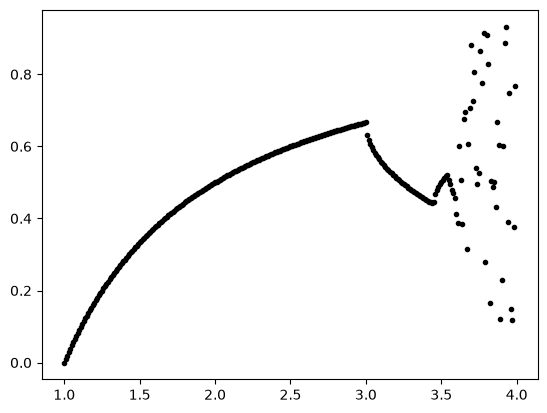

In [144]:
plt.plot(r,x,'k.')

Casi, pero como que faltan puntos. Debe ser porque estos solo son los primeros 1000, pero tengo que graficar los siguientes 1000 para cada r. Puedo hacer si hago una matriz del tamaño de r, con 1000 filas para meter cada nuevo valor de x

In [147]:
x8=np.ones([1000,len(r)]) #creo la matriz
for i in range(1000): #siguientes 1000 iteraciones
    x=r*x*(1-x)
    x8[i]=x #cambio la fila por los nuevos valores de x

/tmp/ipykernel_19326/4059177821.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(r,x8[i],'k.', color='#000000') #lo hice así porque necesito graficar con cada fila de x8.


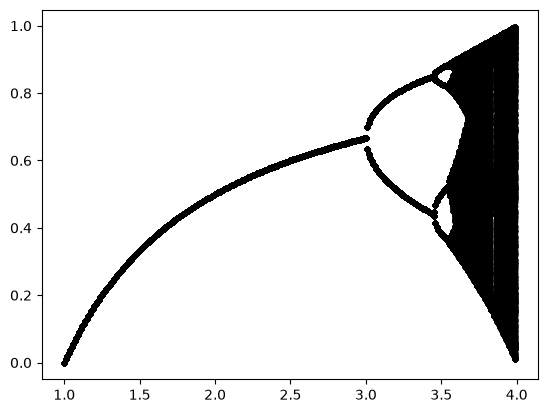

In [151]:
for i in range(1000):
    plt.plot(r,x8[i],'k.', color='#000000') #lo hice así porque necesito graficar con cada fila de x8. Parece ser un poco inconveniente porque hay que graficar mil veces, pero jala wwwww

No sé qué es ese error que me sale ahí, pero bueno

$\textbf{3. El conjunto de Mandelbrot)}$

¿qué?

In [261]:
X=np.linspace(-2,2,500)
Y=np.linspace(-2,2,500)
x,y=np.meshgrid(X,Y) #este es el plano

In [262]:
c = x+1j*y #defino a todos los valores de c. Tuve que investigar esta notación, qué extraño.

In [263]:
z = np.copy(c)
for i in range(len(c)):
    z[i]=0
#hice esto para que los valores de z se puedan operar entrada a entrada con los c, igual que en el ejercicio anterior.
puntos = np.zeros((len(c),len(c))) #voy a necesitar esto con números reales para luego graficar en imshow, esa cosa no recibe complejos.
                                #No importa si no tienen el mismo valor, importa el índice

In [264]:
#ahora debo de realizar las operaciones solo sobre los z adecuados. Puedo extraer estos con z[i][j]
for k in range(100): #iteraciones
    for i in range(len(z)):
        for j in range(len(z)):
            if np.abs(z[i][j]) > 2:
                puntos[i][j]=1 #Saco eso marcándolo como un uno (antes le puse cero, pero los colores salían al revés)
            else:
                z[i][j]=z[i][j]**2 + c[i][j] #a los demás, sí les hago la operación

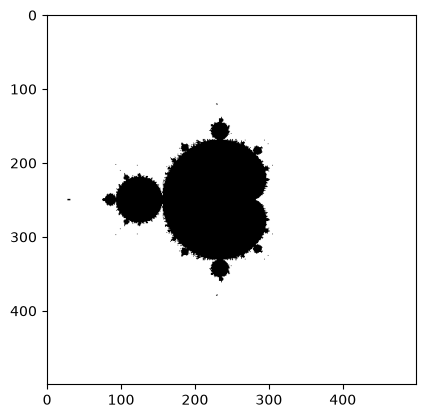

In [265]:
plt.imshow(puntos)
plt.gray()

In [ ]:
intentaaaaaaaaaaaaar

In [22]:
X=np.linspace(-2,2,1000)
Y=np.linspace(-2,2,1000)
x,y=np.meshgrid(X,Y) #este es el plano
c = x+1j*y
z = np.copy(c)
for i in range(len(c)):
    z[i]=0
puntos = np.zeros((len(c),len(c)))
for k in range(150): #iteraciones
    for i in range(len(z)):
        for j in range(len(z)):
            if np.abs(z[i][j]) > 2 and puntos[i][j] == 0: #simplemente agregué otra condición. Que la matriz de arriba no haya sido modificada
                    puntos[i][j]=np.log(k)
            else:
                z[i][j]=z[i][j]**2 + c[i][j]

/tmp/ipykernel_5588/602693081.py:15: RuntimeWarning: overflow encountered in scalar power
  z[i][j]=z[i][j]**2 + c[i][j]
/tmp/ipykernel_5588/602693081.py:15: RuntimeWarning: invalid value encountered in scalar power
  z[i][j]=z[i][j]**2 + c[i][j]


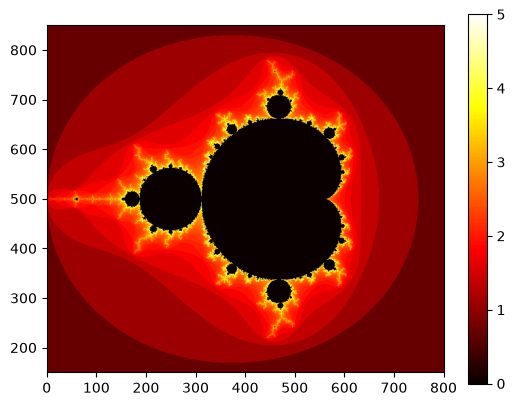

In [32]:
plt.imshow(puntos, cmap ='hot')
plt.xlim(0, 800)
plt.ylim(150,850)
plt.colorbar()
plt.savefig(fname = "conjunto durísimo.jpg")

In [28]:
plt.savefig?

Signature: plt.savefig(fname: 'str | os.PathLike | IO', **kwargs) -> 'None'
Docstring:
Save the current figure as an image or vector graphic to a file.

Call signature::

  savefig(fname, *, transparent=None, dpi='figure', format=None,
          metadata=None, bbox_inches=None, pad_inches=0.1,
          facecolor='auto', edgecolor='auto', backend=None,
          **kwargs
         )

The available output formats depend on the backend being used.

Parameters
----------
fname : str or path-like or binary file-like
    A path, or a Python file-like object, or
    possibly some backend-dependent object such as
    `matplotlib.backends.backend_pdf.PdfPages`.

    If *format* is set, it determines the output format, and the file
    is saved as *fname*.  Note that *fname* is used verbatim, and there
    is no attempt to make the extension, if any, of *fname* match
    *format*, and no extension is appended.

    If *format* is not set, then the format is inferred from the
    extension of *fn